**Objectif: Détection d'anomalies (Anomaly Detection)**

Nous allons chercher les moments où la production s'écarte de la "normale". Une anomalie peut être :

1. Une panne technique (ex: une éolienne à l'arrêt malgré un vent fort).

2. Un événement météo extrême (ex: tempête de poussière occultant le soleil).

**dataset** : https://www.kaggle.com/datasets/henriupton/wind-solar-electricity-production

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Ingestion et Exploration (Obtain & Explore)

In [27]:
# 1. changemenet
df = pd.read_csv('/content/intermittent-renewables-production-france.csv')

In [28]:
# 2. Aperçu des données
df.head(5)

,Date and Hour,Date,StartHour,EndHour,Source,Production,dayOfYear,dayName,monthName
0,2020-07-22 20:00:00+02:00,2020-07-22,20:00:00,21:00:00,Solar,244.0,204,Wednesday,July
1,2020-07-23 07:00:00+02:00,2020-07-23,07:00:00,08:00:00,Solar,223.0,205,Thursday,July
2,2020-07-23 16:00:00+02:00,2020-07-23,16:00:00,17:00:00,Solar,2517.0,205,Thursday,July
3,2020-07-23 19:00:00+02:00,2020-07-23,19:00:00,20:00:00,Solar,658.0,205,Thursday,July
4,2020-07-23 23:00:00+02:00,2020-07-23,23:00:00,24:00:00,Solar,0.0,205,Thursday,July


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59806 entries, 0 to 59805
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date and Hour  59806 non-null  object 
 1   Date           59806 non-null  object 
 2   StartHour      59806 non-null  object 
 3   EndHour        59806 non-null  object 
 4   Source         59806 non-null  object 
 5   Production     59804 non-null  float64
 6   dayOfYear      59806 non-null  int64  
 7   dayName        59806 non-null  object 
 8   monthName      59806 non-null  object 
dtypes: float64(1), int64(1), object(7)
memory usage: 4.1+ MB


In [30]:
print("Colonnes disponibles :", df.columns.tolist())

Colonnes disponibles : ['Date and Hour', 'Date', 'StartHour', 'EndHour', 'Source', 'Production', 'dayOfYear', 'dayName', 'monthName']


In [31]:
# 3. Nettoyage des noms et dates
# Note : Dans ce dataset, la date est souvent dans 'Date and Hour' ou 'Date'
# On va convertir et mettre en index pour faciliter les séries temporelles
df['Date and Hour'] = pd.to_datetime(df['Date and Hour'], utc=True)
df = df.set_index('Date and Hour')

df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 59806 entries, 2020-07-22 18:00:00+00:00 to 2023-06-30 16:00:00+00:00
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Date        59806 non-null  object 
 1   StartHour   59806 non-null  object 
 2   EndHour     59806 non-null  object 
 3   Source      59806 non-null  object 
 4   Production  59804 non-null  float64
 5   dayOfYear   59806 non-null  int64  
 6   dayName     59806 non-null  object 
 7   monthName   59806 non-null  object 
dtypes: float64(1), int64(1), object(6)
memory usage: 4.1+ MB


In [32]:
# Pivoter les données (Reshape)
# On va transformer le tableau pour que chaque source devienne une colonne.
# C'est une manipulation indispensable en Data Engineering.

In [33]:
# On pivote le tableau pour avoir 'Solar' et 'Wind' en colonnes
df_pivot = df.pivot_table(values='Production', index=df.index, columns='Source')

# On renomme pour que ce soit plus clair
df_pivot.columns = ['Eolien', 'Solaire']

# On remplit les éventuels vides par 0 (pas de prod)
df_pivot = df_pivot.fillna(0)

df_pivot

,Eolien,Solaire
Date and Hour,,
2019-12-31 23:00:00+00:00,0.0,3549.0
2020-01-01 00:00:00+00:00,0.0,2952.0
2020-01-01 01:00:00+00:00,0.0,2722.0
2020-01-01 02:00:00+00:00,0.0,2753.0
2020-01-01 03:00:00+00:00,0.0,2707.0
...,...,...
2023-06-30 17:00:00+00:00,1273.0,5742.0
2023-06-30 18:00:00+00:00,439.0,5152.0
2023-06-30 19:00:00+00:00,50.0,4857.0


**2. Exploration et Saisonnalité (Explore)**

Dans le secteur de l'énergie au Sénégal, on observe une forte saisonnalité. Le solaire produit au max entre 11h et 15h. Pour détecter une anomalie, il faut d'abord voir cette "vague" quotidienne.

Visualisons la moyenne de production par heure de la journée :

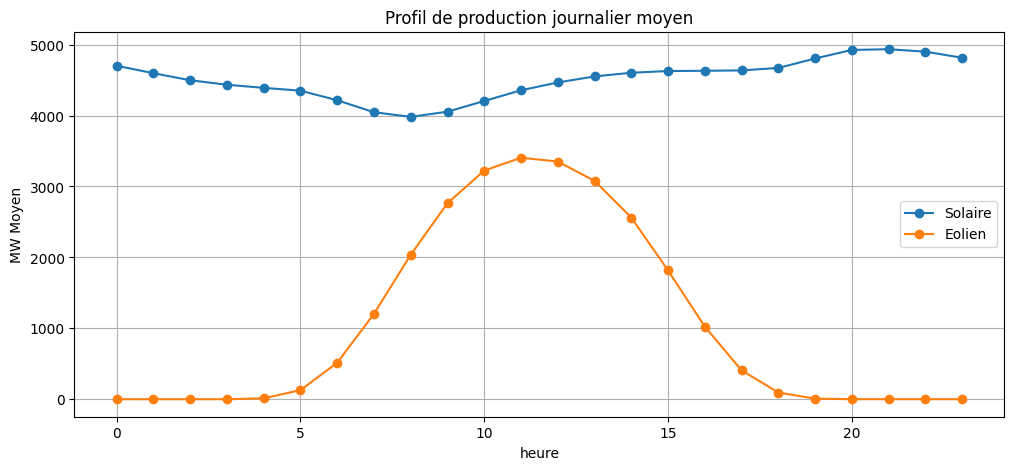

In [34]:
# Création d'une colonne heure
df_pivot['heure'] = df_pivot.index.hour

# Moyenne de production par heure
hourly_profile = df_pivot.groupby('heure')[['Solaire', 'Eolien']].mean()

# Affichage du profil journalier type
hourly_profile.plot(kind='line', marker='o', figsize=(12, 5))
plt.title("Profil de production journalier moyen")
plt.ylabel('MW Moyen')
plt.grid(True)
plt.show()

**Interprétation de ton profil journalier**

* La courbe Orange (Solaire) : Elle forme cette magnifique "cloche". Elle commence à 0 MW à l'heure 0 (minuit) et ne décolle qu'après l'heure 5. Elle atteint son maximum vers 11h-12h avant de redescendre à 0 vers 20h. C'est la signature thermique et lumineuse de notre journée.

* La courbe Bleue (Éolien) : Elle est beaucoup plus plate mais reste élevée tout au long des 24 heures. Elle semble même remonter légèrement le soir. C'est ce qu'on appelle une énergie de base plus stable que le solaire sur 24h, bien qu'elle soit imprévisible d'un jour à l'autre.

I**dentifier les "Vraies" Anomalies**

on va filtrer les anomalies pour ne garder que celles qui comptent : les chutes de production en plein jour.

# 3. Détection d'anomalies (Scrub & Explore)

Maintenant, cherchons les "monstres". Une anomalie solaire intéressante pour la SENELEC, c'est quand la production s'effondre alors qu'il fait grand jour.

Calculons le Z-Score (Écart à la normale) : On va comparer chaque point à la moyenne de son heure spécifique.

In [35]:
# 1. Calculer une moyenne mobile sur les 3 dernières heures (fenêtre de 3)
df_pivot['moyenne_mobile'] = df_pivot['Solaire'].rolling(window=3, center=True).mean()

# 2. Calculer l'écart par rapport à cette moyenne mobile
df_pivot['ecart_mobile'] = df_pivot['Solaire'] - df_pivot['moyenne_mobile']

# 3. Définir une anomalie comme une chute de plus de 50% par rapport à la moyenne mobile
# (Uniquement quand il y a du soleil, donc Solaire > 100)
anomalies_mobiles = df_pivot[(df_pivot['Solaire'] < df_pivot['moyenne_mobile'] * 0.5) & (df_pivot['Solaire'] > 100)]

print(f"Nouvelles anomalies détectées : {len(anomalies_mobiles)}")

Nouvelles anomalies détectées : 0


In [36]:
# Calcul de la moyenne et de l'écart-type par heure
stats_par_heure = df_pivot.groupby('heure')['Solaire'].agg(['mean', 'std'])

# On fusionne ces stats avec notre dataset principal
df_pivot = df_pivot.merge(stats_par_heure, on='heure')


In [37]:
# Calcul du Z-Score : (Valeur - Moyenne) / Écart-type
df_pivot['z_score_solaire'] = (df_pivot['Solaire'] - df_pivot['mean']) / df_pivot['std']

# Une anomalie est souvent définie par un Z-Score < -2 (production anormalement basse)
anomalies_solaires = df_pivot[df_pivot['z_score_solaire'] < - 2]

print(f"Nombre d'anomalies solaires détectées : {len(anomalies_solaires)}")

Nombre d'anomalies solaires détectées : 0


In [38]:
df_pivot.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29901 entries, 0 to 29900
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Eolien           29901 non-null  float64
 1   Solaire          29901 non-null  float64
 2   heure            29901 non-null  int32  
 3   moyenne_mobile   29899 non-null  float64
 4   ecart_mobile     29899 non-null  float64
 5   mean             29901 non-null  float64
 6   std              29901 non-null  float64
 7   z_score_solaire  29901 non-null  float64
dtypes: float64(7), int32(1)
memory usage: 1.7 MB


# 4. Analyse de Corrélation (Interprétation)

Puisque nous avons l'Éolien et le Solaire, au lieu de chercher des pannes, regardons comment ils travaillent ensemble.c'est ce qu'on appelle le mix énergétique.

L'idée est de vérifier si, quand le solaire baisse (le soir), l'éolien prend le relais.

In [39]:
# 1. Calcul de la corrélation
correlation = df_pivot[['Solaire', 'Eolien']].corr()

correlation

,Solaire,Eolien
Solaire,1.000000,-0.169933
Eolien,-0.169933,1.000000


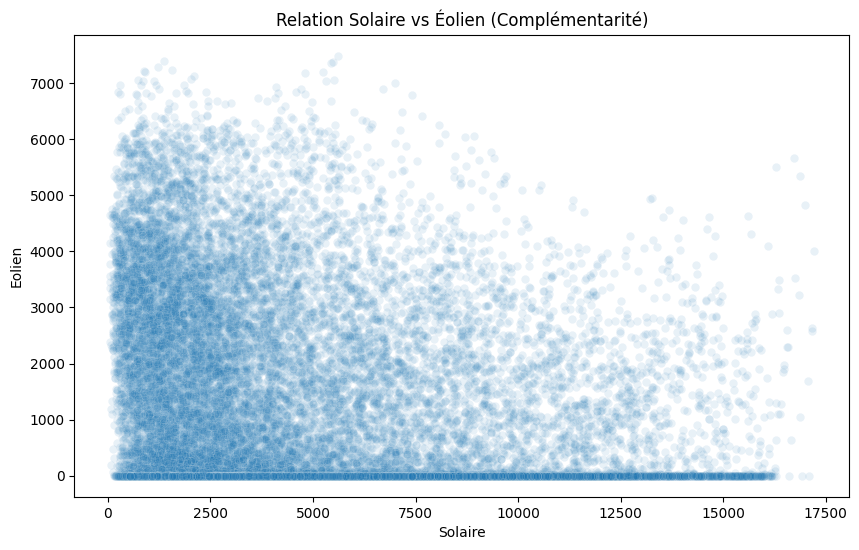

In [40]:
# 2. Visualisation de la relation
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_pivot, x='Solaire', y='Eolien', alpha=0.1)
plt.title("Relation Solaire vs Éolien (Complémentarité)")
plt.show()

Interpretations:

Complémentarité : Cela signifie que quand la production solaire baisse, l'éolien ne baisse pas forcément en même temps.

Stabilité du réseau : Si la corrélation était de +1.0, les deux énergies s'arrêteraient en même temps, créant un risque de black-out total.

Mix Énergétique : Au Sénégal, cette indépendance permet de lisser la production totale sur 24h.

# 5. Le Modèle de Prédiction (Model)

1. Préparation des données (Feature Engineering)

In [41]:
# On crée le 'lag' (décalage) pour le solaire
df_pivot['Solaire_H-1'] = df_pivot['Solaire'].shift(1)

# On crée aussi des indicateurs temporels car le soleil dépend de l'heure
df_pivot

,Eolien,Solaire,heure,moyenne_mobile,ecart_mobile,mean,std,z_score_solaire,Solaire_H-1
0,0.0,3549.0,23,NaN,NaN,4814.540931,3301.453967,-0.383328,NaN
1,0.0,2952.0,0,3074.333333,-122.333333,4702.239743,3280.809039,-0.533478,3549.0
2,0.0,2722.0,1,2809.000000,-87.000000,4596.624799,3250.419374,-0.576733,2952.0
3,0.0,2753.0,2,2727.333333,25.666667,4497.594703,3227.899982,-0.540474,2722.0
4,0.0,2707.0,3,2679.666667,27.333333,4434.513644,3222.895909,-0.536013,2753.0
...,...,...,...,...,...,...,...,...,...
29896,1273.0,5742.0,17,5568.333333,173.666667,4636.398074,3494.954236,0.316342,5811.0
29897,439.0,5152.0,18,5250.333333,-98.333333,4671.002408,3457.331330,0.139124,5742.0
29898,50.0,4857.0,19,5049.666667,-192.666667,4804.179775,3435.281519,0.015376,5152.0
29899,1.0,5140.0,20,5377.333333,-237.333333,4925.030498,3394.194585,0.063334,4857.0
